### Загрузка данных

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder


df_train = pd.read_csv('data.txt', sep=',')
df_train.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=N
0,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=N
1,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=N
2,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=N
3,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=N
4,37,Private,284582.0,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0.0,0.0,40,United-States,<=N


Видно, что у столбцов нет заголовков, исправляем согласно описанию задания

In [83]:
features = [
    'age', 'workclass', 'final_weight', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'cap-gain', 'cap-loss', 'hours-per-week', 'native-country'
]

df_train = pd.read_csv('data.txt', names=features + ['salary'], sep=',', na_values='?')
df_train.head()

,age,workclass,final_weight,education,education-num,marital-status,occupation,relationship,race,sex,cap-gain,cap-loss,hours-per-week,native-country,salary
0,39,State-gov,77516.0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40,United-States,<=N
1,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=N
2,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=N
3,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=N
4,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=N


### Анализ данных

In [84]:
print(f'Size: {df_train.shape}')
print(df_train.dtypes)

Size: (32573, 15)
age                object
workclass          object
final_weight      float64
education          object
education-num      object
marital-status     object
occupation         object
relationship       object
race               object
sex                object
cap-gain          float64
cap-loss          float64
hours-per-week     object
native-country     object
salary             object
dtype: object


In [85]:
print(df_train.isnull().sum())

age               0
workclass         1
final_weight      1
education         1
education-num     1
marital-status    1
occupation        1
relationship      1
race              1
sex               1
cap-gain          1
cap-loss          1
hours-per-week    1
native-country    1
salary            2
dtype: int64


In [86]:
df_train.describe()

,final_weight,cap-gain,cap-loss
count,3.257200e+04,32572.000000,32572.000000
mean,7.099108e+12,1077.315578,87.226943
std,1.281227e+15,7384.067167,402.917749
min,-4.214100e+04,-1.000000,-444.000000
25%,1.177890e+05,0.000000,0.000000
50%,1.783485e+05,0.000000,0.000000
75%,2.370065e+05,0.000000,0.000000
max,2.312322e+17,99999.000000,4356.000000


In [87]:
for col in df_train.columns:
    print(f'\n{df_train[col].value_counts().head(10)}')


age
36    898
31    888
34    886
23    877
35    876
33    875
28    867
30    861
37    858
25    841
Name: count, dtype: int64

workclass
Private             22697
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1308
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

final_weight
164190.0    13
203488.0    13
123011.0    13
121124.0    12
148995.0    12
126675.0    12
113364.0    12
120277.0    11
102308.0    11
190290.0    11
Name: count, dtype: int64

education
HS-grad         10501
Some-college     7302
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64

education-num
9     10501
10     7301
13     5355
14     1723
11     1382
7      1175
12     1067
6       933
4       646
15      576
Name: count, dty

salary
<=N    24720
>N      7851
Name: count, dtype: int64


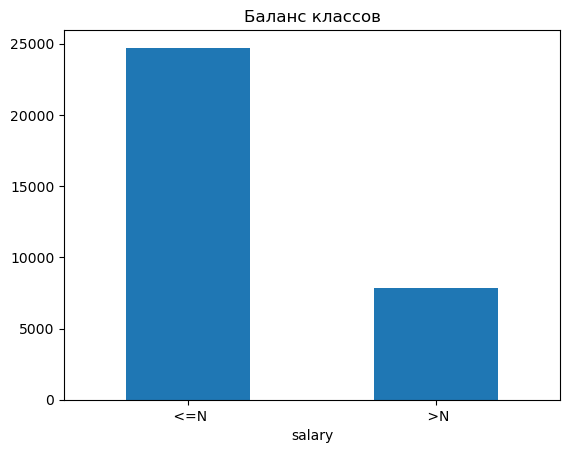

In [88]:
target = 'salary'
print(df_train[target].value_counts())

ax = df_train[target].value_counts().plot(kind='bar')
ax.set_title('Баланс классов')
ax.tick_params(axis='x', rotation=0)
plt.show()

Кодирование таргета

In [93]:
le = LabelEncoder()
df_train[target] = le.fit_transform(df_train[target])

Замена null значений на моду(категориальные данные) и медиану(числовые)

In [94]:
num_features = [
    'age', 'final_weight', 'education-num', 'cap-gain', 'cap-loss', 'hours-per-week'
]
categ_features = [
    'workclass', 'education', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'native-country'
]

df_train[num_features] = df_train[num_features].apply(pd.to_numeric, errors='coerce')
   
for categ in categ_features:
    df_train[categ] = df_train[categ].fillna(df_train[categ].mode())

for num in num_features:
    df_train[num] = df_train[num].fillna(df_train[num].median())

print(df_train.isnull().sum())

age               0
workclass         1
final_weight      0
education         1
education-num     0
marital-status    1
occupation        1
relationship      1
race              1
sex               1
cap-gain          0
cap-loss          0
hours-per-week    0
native-country    1
salary            0
dtype: int64


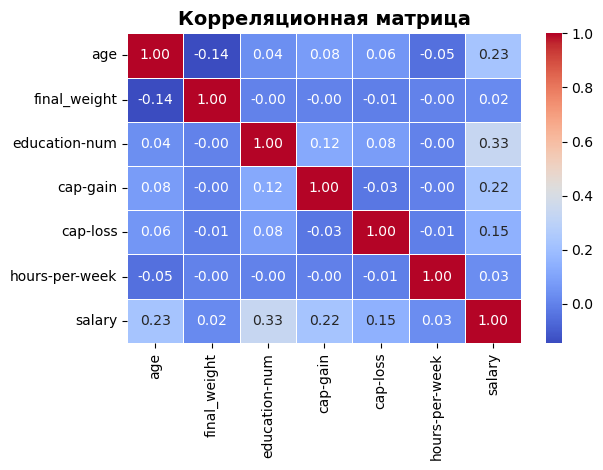

In [106]:
plt.figure()
corr_matrix = df_train[num_features + ['salary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()